In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

C:\Users\hercd\AppData\Local\Temp\ipykernel_4348\2696667154.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_4348\3661565427.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_new_csv.csv", index_col= "datetime", parse_dates= True)


,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0.0,"Kozani, Greece",0.0,0.0,-12.0,40.02,0.0,0.0,0.0,23.0,3.6,292.9,1024.0,45.3,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2020-01-01 01:00:00,0.0,"Kozani, Greece",1.0,1.0,-11.0,40.33,0.0,0.0,0.0,23.4,1.8,300.4,1023.0,94.1,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 02:00:00,0.0,"Kozani, Greece",2.0,0.5,-12.0,34.62,0.0,NaN,0.0,22.2,5.4,293.6,1026.2,99.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 03:00:00,0.0,"Kozani, Greece",2.0,-0.8,-12.0,34.66,0.0,NaN,0.0,23.0,9.4,270.0,1023.0,98.4,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 04:00:00,0.0,"Kozani, Greece",2.0,2.0,-11.0,37.54,0.0,NaN,0.0,24.8,3.6,298.2,1022.0,95.2,NaN,0.0,0.0,0.0,Overcast,cloudy


In [3]:
data

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0.0000,"Kozani, Greece",0.0,0.0,-12.0,40.02,0.0,0.0,0.0,23.0,3.6,292.9,1024.0,45.3,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2020-01-01 01:00:00,0.0000,"Kozani, Greece",1.0,1.0,-11.0,40.33,0.0,0.0,0.0,23.4,1.8,300.4,1023.0,94.1,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 02:00:00,0.0000,"Kozani, Greece",2.0,0.5,-12.0,34.62,0.0,NaN,0.0,22.2,5.4,293.6,1026.2,99.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 03:00:00,0.0000,"Kozani, Greece",2.0,-0.8,-12.0,34.66,0.0,NaN,0.0,23.0,9.4,270.0,1023.0,98.4,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 04:00:00,0.0000,"Kozani, Greece",2.0,2.0,-11.0,37.54,0.0,NaN,0.0,24.8,3.6,298.2,1022.0,95.2,NaN,0.0,0.0,0.0,Overcast,cloudy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,0.0592,"Kozani, Greece",24.0,24.0,10.0,41.15,0.0,0.0,0.0,22.0,9.4,180.0,1010.0,79.3,NaN,207.0,0.7,2.0,Partially cloudy,partly-cloudy-day
2024-07-04 20:00:00,0.0085,"Kozani, Greece",23.0,23.0,9.0,40.87,0.1,0.0,0.0,22.0,3.6,172.8,1010.0,81.7,NaN,103.0,0.4,1.0,"Rain, Partially cloudy",rain
2024-07-04 21:00:00,0.0000,"Kozani, Greece",21.0,21.0,10.0,49.39,0.1,0.0,0.0,14.4,0.0,0.0,1011.0,63.7,NaN,9.0,0.0,0.0,"Rain, Partially cloudy",rain


In [4]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2020-01-01 13:00:00  0.4745  Kozani, Greece   7.0        2.8  -9.0     30.99   
 2020-01-02 13:00:00  0.4737  Kozani, Greece   3.0       -2.4  -9.0     40.94   
 2020-01-03 13:00:00  0.4767  Kozani, Greece   7.0        4.2 -13.0     22.54   
 2020-01-04 13:00:00  0.4719  Kozani, Greece  11.0       11.0  -8.0     25.58   
 2020-01-05 13:00:00  0.1833  Kozani, Greece   4.0       -0.7  -2.0     64.94   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [5]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

C:\Users\hercd\AppData\Local\Temp\ipykernel_4348\1967777196.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['solarradiation'].fillna(mean_13_00, inplace=True)


In [6]:
kwh_data = data[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'conditions']]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions
datetime,,,,,,,
2020-01-01 00:00:00,0.0,40.02,23.0,292.9,45.3,0.0,Partially cloudy
2020-01-01 01:00:00,1.0,40.33,23.4,300.4,94.1,0.0,Overcast
2020-01-01 02:00:00,2.0,34.62,22.2,293.6,99.0,0.0,Overcast
2020-01-01 03:00:00,2.0,34.66,23.0,270.0,98.4,0.0,Overcast
2020-01-01 04:00:00,2.0,37.54,24.8,298.2,95.2,0.0,Overcast
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,Partially cloudy
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,"Rain, Partially cloudy"
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,"Rain, Partially cloudy"


In [7]:
kwh_data.describe()

,temp,humidity,windgust,winddir,cloudcover,solarradiation
count,39527.000000,39527.000000,39527.000000,39527.000000,39527.000000,39527.000000
mean,13.402348,59.659390,18.274584,216.711344,46.019260,178.145351
std,8.848400,22.784654,9.922733,134.087883,37.416352,263.133844
min,-10.000000,6.520000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,41.440000,11.200000,100.000000,7.700000,0.000000
50%,13.000000,58.500000,15.800000,280.000000,41.200000,11.300000
75%,20.000000,77.460000,23.000000,340.000000,88.300000,308.000000
max,40.000000,100.000000,74.200000,360.000000,100.000000,1157.000000


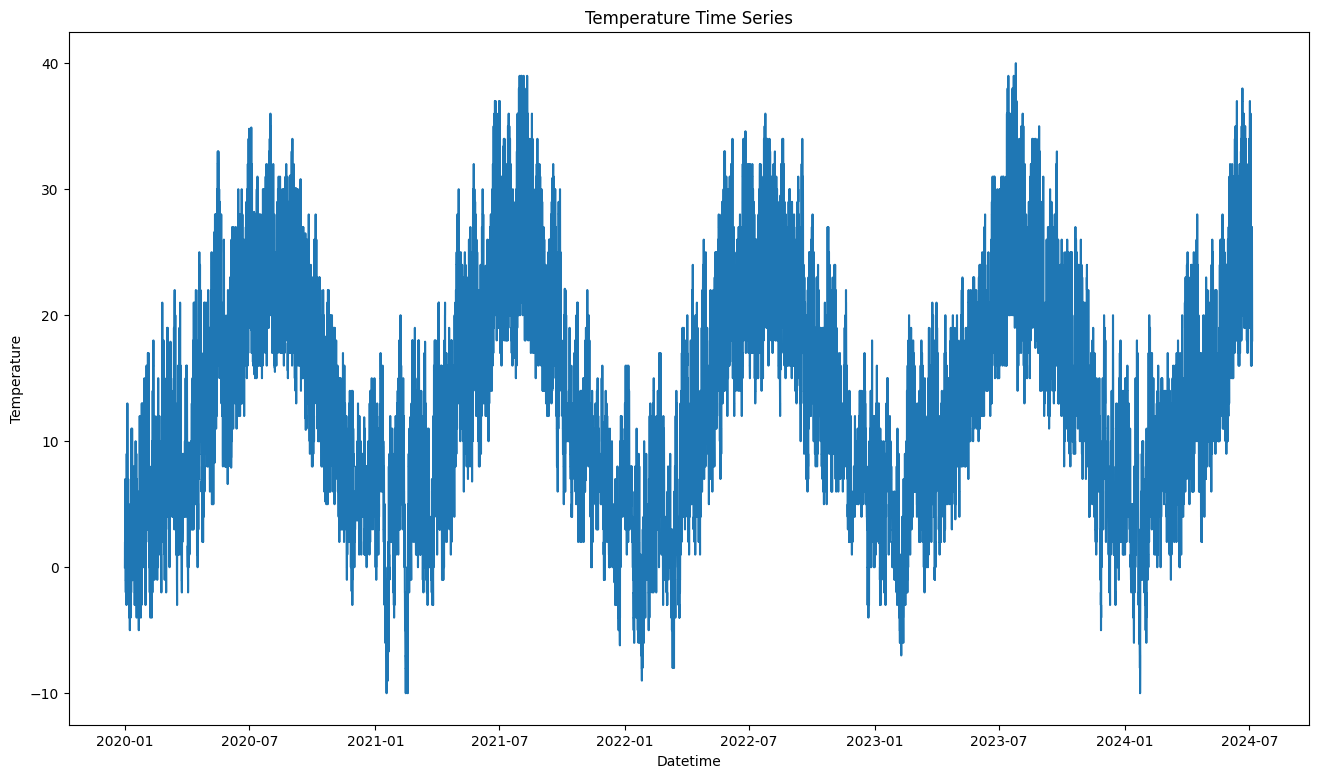

In [8]:
plt.figure(figsize = (16, 9))
sns.lineplot(x = kwh_data.index, y = kwh_data['temp'])
plt.xlabel("Datetime")
plt.ylabel("Temperature")
plt.title("Temperature Time Series")
plt.show()

In [9]:
kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])
kwh_data = kwh_data.drop('conditions', axis= 1)

kwh_data

C:\Users\hercd\AppData\Local\Temp\ipykernel_4348\2953575604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])


,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int
datetime,,,,,,,
2020-01-01 00:00:00,0.0,40.02,23.0,292.9,45.3,0.0,2
2020-01-01 01:00:00,1.0,40.33,23.4,300.4,94.1,0.0,1
2020-01-01 02:00:00,2.0,34.62,22.2,293.6,99.0,0.0,1
2020-01-01 03:00:00,2.0,34.66,23.0,270.0,98.4,0.0,1
2020-01-01 04:00:00,2.0,37.54,24.8,298.2,95.2,0.0,1
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,2
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,5
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,5


In [10]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int,Kwh
datetime,,,,,,,,
2020-01-01 00:00:00,0.0,40.02,23.0,292.9,45.3,0.0,2,0.0000
2020-01-01 01:00:00,1.0,40.33,23.4,300.4,94.1,0.0,1,0.0000
2020-01-01 02:00:00,2.0,34.62,22.2,293.6,99.0,0.0,1,0.0000
2020-01-01 03:00:00,2.0,34.66,23.0,270.0,98.4,0.0,1,0.0000
2020-01-01 04:00:00,2.0,37.54,24.8,298.2,95.2,0.0,1,0.0000
...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,2,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,5,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,5,0.0000


In [11]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :8])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5,6,7
0,-1.514683,-0.861968,0.476227,0.568207,-0.019223,-0.677023,0.619523,-0.672085
1,-1.401666,-0.848362,0.516539,0.624141,1.285036,-0.677023,-0.263719,-0.672085
2,-1.288650,-1.098972,0.395603,0.573427,1.415996,-0.677023,-0.263719,-0.672085
3,-1.288650,-1.097217,0.476227,0.397421,1.399960,-0.677023,-0.263719,-0.672085
4,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-0.672085
5,-1.401666,-0.700454,0.244433,0.844894,1.204856,-0.677023,-0.263719,-0.672085
6,-1.175634,-0.821589,1.020439,0.994052,-0.208982,-0.677023,0.619523,-0.672085
7,-1.288650,-0.532795,1.171609,0.770315,-1.029490,-0.677023,-1.146960,-0.672085
8,-1.288650,-0.531478,2.441437,0.844894,-1.053544,-0.642819,-1.146960,-0.444251
9,-1.175634,-0.675875,3.015882,0.994052,-1.000090,-0.540209,-1.146960,0.262345


In [12]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2,3,4,5,6,7
datetime,,,,,,,,
2020-01-01 00:00:00,-1.514683,-0.861968,0.476227,0.568207,-0.019223,-0.677023,0.619523,-0.672085
2020-01-01 01:00:00,-1.401666,-0.848362,0.516539,0.624141,1.285036,-0.677023,-0.263719,-0.672085
2020-01-01 02:00:00,-1.288650,-1.098972,0.395603,0.573427,1.415996,-0.677023,-0.263719,-0.672085
2020-01-01 03:00:00,-1.288650,-1.097217,0.476227,0.397421,1.399960,-0.677023,-0.263719,-0.672085
2020-01-01 04:00:00,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-0.672085
...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.197706,-0.812372,0.375447,-0.273789,0.889482,0.109659,0.619523,-0.409165
2024-07-04 20:00:00,1.084690,-0.824662,0.375447,-0.327486,0.953626,-0.285582,3.269247,-0.634334
2024-07-04 21:00:00,0.858658,-0.450721,-0.390480,-1.616209,0.472546,-0.642819,3.269247,-0.672085


In [13]:
df_scaled_kwh = pd.concat([df_scaled_kwh, data["Kwh"]], axis=1)
df_scaled_kwh


,0,1,2,3,4,5,6,7,Kwh
datetime,,,,,,,,,
2020-01-01 00:00:00,-1.514683,-0.861968,0.476227,0.568207,-0.019223,-0.677023,0.619523,-0.672085,0.0000
2020-01-01 01:00:00,-1.401666,-0.848362,0.516539,0.624141,1.285036,-0.677023,-0.263719,-0.672085,0.0000
2020-01-01 02:00:00,-1.288650,-1.098972,0.395603,0.573427,1.415996,-0.677023,-0.263719,-0.672085,0.0000
2020-01-01 03:00:00,-1.288650,-1.097217,0.476227,0.397421,1.399960,-0.677023,-0.263719,-0.672085,0.0000
2020-01-01 04:00:00,-1.288650,-0.970814,0.657631,0.607733,1.314435,-0.677023,-0.263719,-0.672085,0.0000
...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.197706,-0.812372,0.375447,-0.273789,0.889482,0.109659,0.619523,-0.409165,0.0592
2024-07-04 20:00:00,1.084690,-0.824662,0.375447,-0.327486,0.953626,-0.285582,3.269247,-0.634334,0.0085
2024-07-04 21:00:00,0.858658,-0.450721,-0.390480,-1.616209,0.472546,-0.642819,3.269247,-0.672085,0.0000


In [14]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :8]]
        x.append(row)
        real_val = df_as_np[i + size][8]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [15]:
x_kwh, y_kwh = df_to_x_y(df_scaled_kwh, size=24)
x_kwh.shape, y_kwh.shape

x_train_kwh, y_train_kwh = x_kwh[:int(0.8*len(x_kwh))], y_kwh[:int(0.8*len(y_kwh))]
x_val_kwh, y_val_kwh = x_kwh[int(0.8*len(x_kwh)):int(0.9*len(x_kwh))], y_kwh[int(0.8*len(y_kwh)):int(0.9*len(y_kwh))]
x_test_kwh, y_test_kwh = x_kwh[int(0.9*len(x_kwh)):], y_kwh[int(0.9*len(y_kwh)):]

x_train_kwh.shape, y_train_kwh.shape, x_val_kwh.shape, y_val_kwh.shape, x_test_kwh.shape, y_test_kwh.shape

((31602, 24, 8), (31602,), (3950, 24, 8), (3950,), (3951, 24, 8), (3951,))

In [16]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [17]:
input_shape = (24, 8)

inputs = Input(shape=input_shape)

cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(cnn_out)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

query = cnn_out
value = cnn_out
attention_out = Attention()([query, value])

lstm_out = LSTM(64, return_sequences=True)(cnn_out)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out
attention_out = Attention()([query, value])

dropout_out = Dropout(0.3)(attention_out)

dense_out = Dense(128, activation="relu")(dropout_out)

flattened = BatchNormalization()(dense_out)
flattened = GlobalAveragePooling1D()(flattened)

outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │      1,600 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 12, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 12, 64)    │        256 │ max_pooling1d[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 6, 128)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ max_pooling1d_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 6, 64)     │     49,408 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 64)     │        256 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 6, 64)     │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 6, 64)     │          0 │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 128)    │      8,320 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 85,697 (334.75 KB)

 Trainable params: 84,929 (331.75 KB)

 Non-trainable params: 768 (3.00 KB)

In [18]:
history = model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=16,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

Epoch 1/40
1971/1976 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0548 - root_mean_squared_error: 0.2276
Epoch 1: val_loss improved from inf to 0.00724, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0547 - root_mean_squared_error: 0.2274 - val_loss: 0.0072 - val_root_mean_squared_error: 0.0851 - learning_rate: 0.0010
Epoch 2/40
1971/1976 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0108 - root_mean_squared_error: 0.1040
Epoch 2: val_loss improved from 0.00724 to 0.00681, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0108 - root_mean_squared_error: 0.1040 - val_loss: 0.0068 - val_root_mean_squared_error: 0.0825 - learning_rate: 0.0010
Epoch 3/40
1974/1976 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0070 - root_mean_squared_error: 0.0835
Epoch 3: val_loss improved from 0.00681 to 0.00504, saving model to D:/

In [19]:
test_predictions_kwh = model_1.predict(x_test_kwh).flatten()
test_results_kwh = pd.DataFrame({"Val Predictions": test_predictions_kwh, "Real Data": y_test_kwh})
test_results_kwh
test_results_kwh.index = kwh_data.iloc[-3951:].index

124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


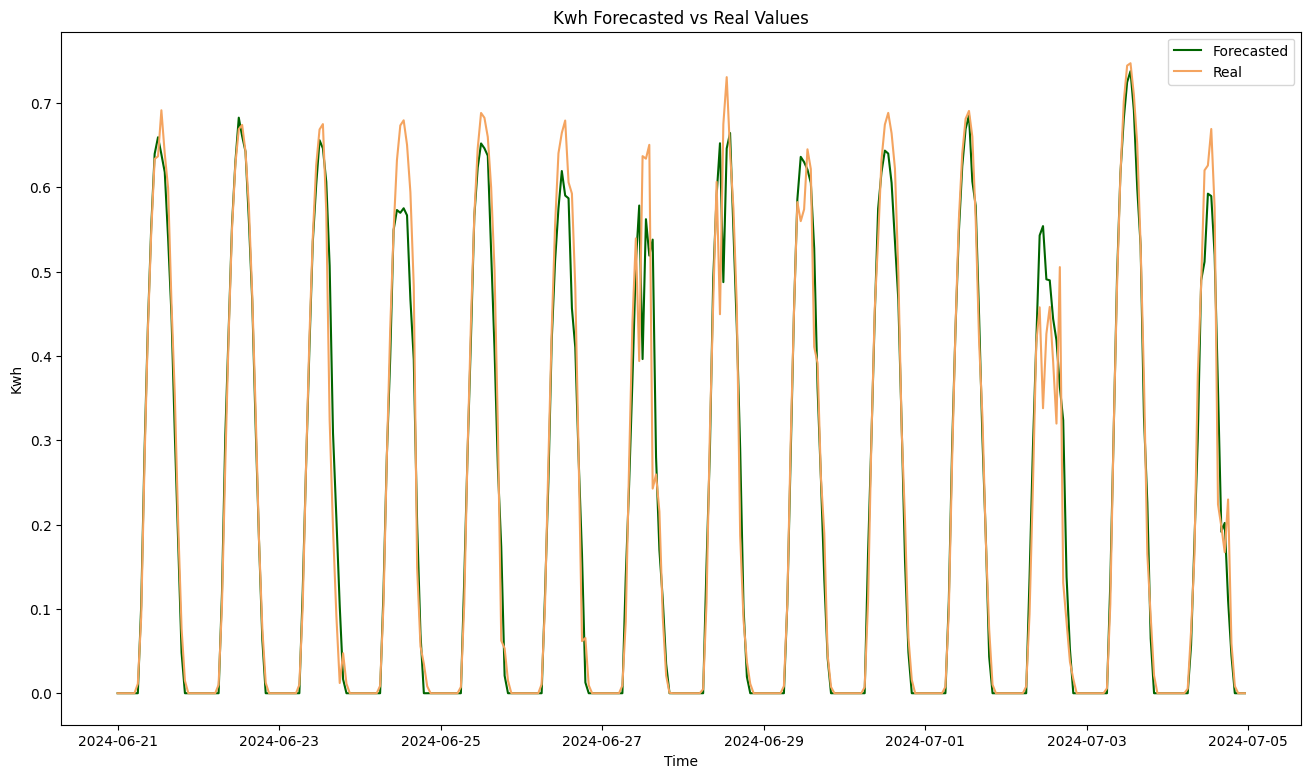

In [24]:
plt.figure(figsize=(16, 9))
sns.lineplot(x = test_results_kwh.index[-336: ], y = test_results_kwh["Val Predictions"][-336: ], label="Forecasted", color = 'DarkGreen')
sns.lineplot(x = test_results_kwh.index[-336: ], y = test_results_kwh["Real Data"][-336: ], label="Real", color = 'SandyBrown')
plt.legend()
plt.ylabel("Kwh")
plt.xlabel("Time")
plt.title("Kwh Forecasted vs Real Values")
plt.show()


In [21]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Val Predictions"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Val Predictions"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)

r_squared_kwh, mse_kwh    #0.9412

Mean Squared Error = 0.00319 
Root Mean Squared Error = 0.05648


(0.9412128863190042, 0.003190259200781969)

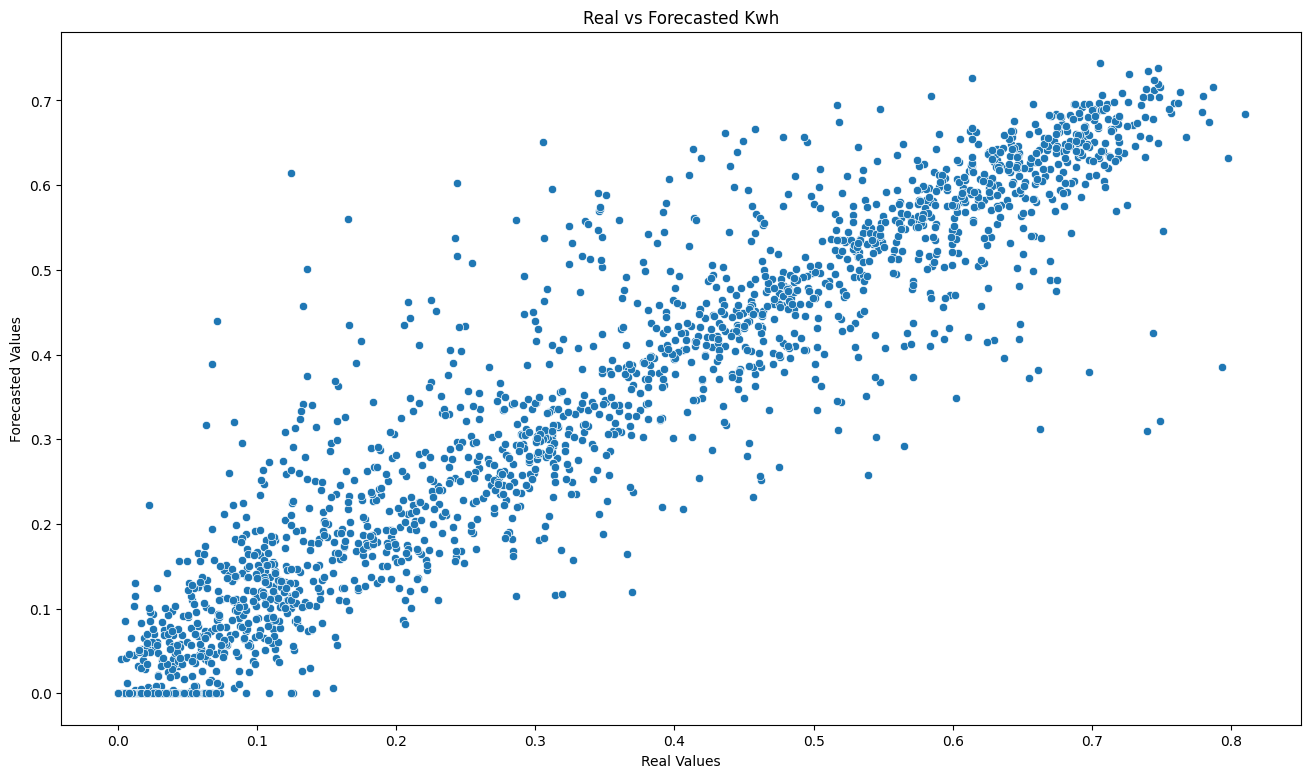

In [22]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = test_results_kwh)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.title("Real vs Forecasted Kwh")
plt.show()

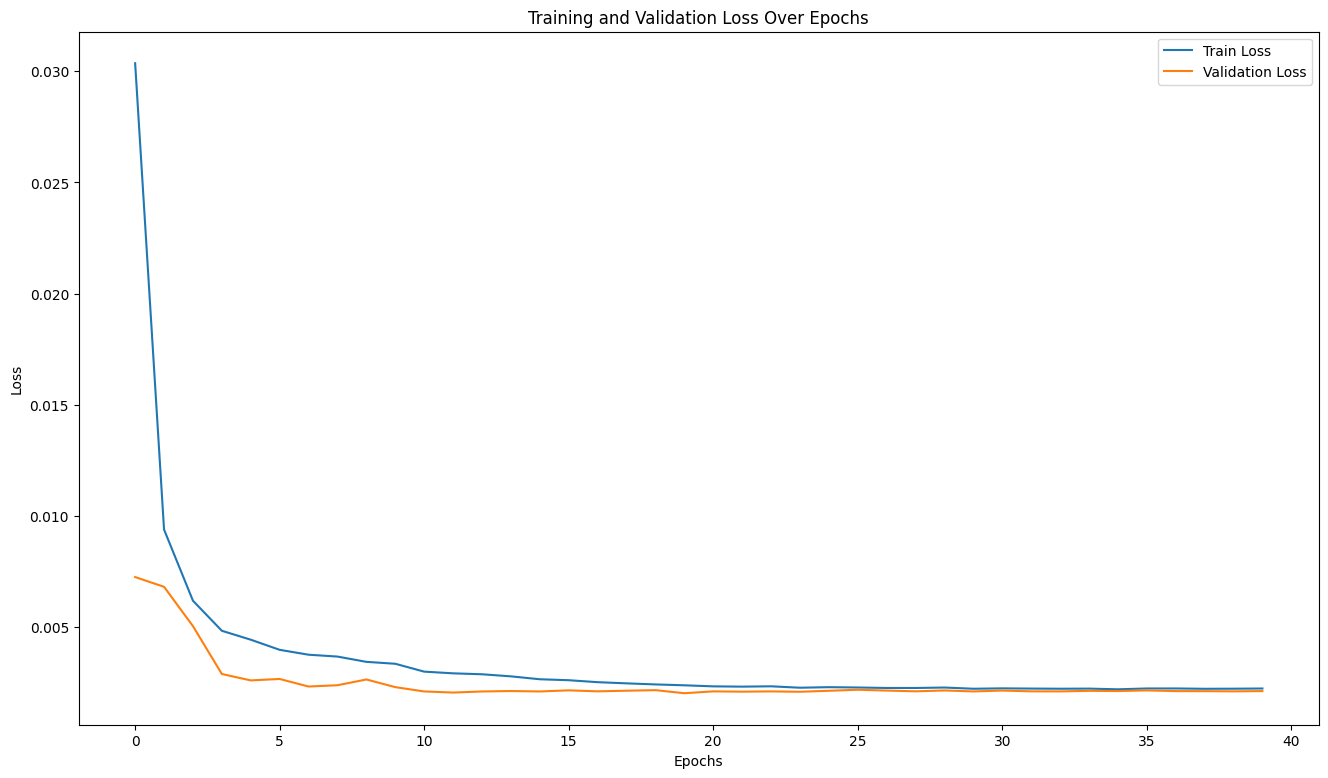

In [23]:
plt.figure(figsize = (16, 9))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()